In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("data/fraud_detection.csv")
print(f"Shape: {df.shape}")
print(f"\nDtype: \n{df.dtypes}")
print(df.info())
print(df.describe)
print(f"5 first rows: {df.head()}")

Shape: (3000, 15)

Dtype: 
transaction_amount        float64
transaction_hour            int64
transaction_day            object
merchant_category          object
payment_method             object
customer_age                int64
account_age_months          int64
avg_monthly_spend         float64
num_transactions_30d        int64
num_countries_30d           int64
failed_transactions_7d    float64
velocity_1h                 int64
distance_from_home_km     float64
is_foreign_transaction      int64
is_fraud                    int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_amount      2897 non-null   float64
 1   transaction_hour        3000 non-null   int64  
 2   transaction_day         3000 non-null   object 
 3   merchant_category       3000 non-null   object 
 4   payment_method     

In [3]:
print("=== Class imbalance check ===")
counts = df['is_fraud'].value_counts()
pct = df['is_fraud'].value_counts(normalize=True) * 100
print(f"Is fraud (1) {counts[1]} - percentage: {pct[1]}%")
print(f"Is fraud (0) {counts[0]} - percentage: {pct[0]}%")

print("=== Missing value check ===")
missing_value = df.isnull().sum()
pct_missing = missing_value / len(df) * 100

report = pd.DataFrame({"Count":  missing_value, "Percentage" : pct_missing})
print(report[report['Count'] > 0].round(2))

=== Class imbalance check ===
Is fraud (1) 1245 - percentage: 41.5%
Is fraud (0) 1755 - percentage: 58.5%
=== Missing value check ===
                        Count  Percentage
transaction_amount        103        3.43
avg_monthly_spend         130        4.33
failed_transactions_7d     86        2.87
distance_from_home_km     154        5.13


In [4]:
print("=== Outliers Check ===")
numeric_cols = df.select_dtypes(['float64'], ['int64']).columns

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    if outliers > 0:
        print(f"Col {col} have {outliers} outliers - range [{lower:.1f}, {upper:.1f}]")

=== Outliers Check ===
Col transaction_amount have 144 outliers - range [-215.0, 469.4]
Col avg_monthly_spend have 7 outliers - range [-269.1, 1858.1]
Col failed_transactions_7d have 176 outliers - range [-1.5, 2.5]
Col distance_from_home_km have 137 outliers - range [-26.1, 58.6]


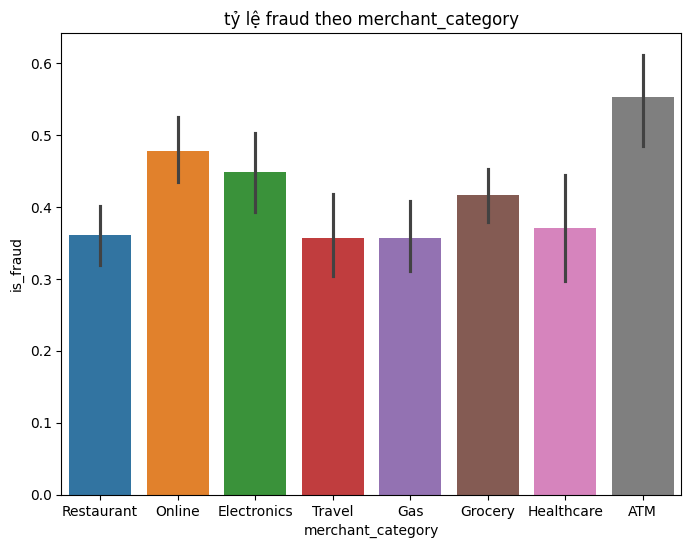

In [5]:
plt.figure(figsize=(8,6))

sns.barplot(
    data = df,
    y = 'is_fraud',
    x = 'merchant_category',
    hue = 'merchant_category'
)

plt.title('tỷ lệ fraud theo merchant_category')
plt.show()

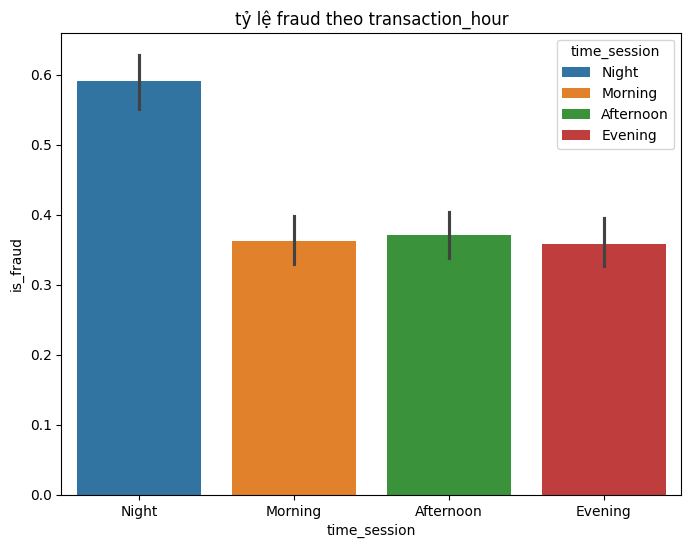

In [6]:
bins = [0 , 5 , 11, 17, 23]
labels = ['Night', 'Morning', 'Afternoon', "Evening"]

df['time_session'] = pd.cut(df['transaction_hour'], bins = bins, labels = labels)

plt.figure(figsize = (8,6))
sns.barplot(
    data = df,
    x = 'time_session',
    y = 'is_fraud',
    hue = 'time_session'
)

plt.title("tỷ lệ fraud theo transaction_hour")
plt.show()

In [7]:
print("=== Drop Outliers ===")
df = df[(df['transaction_amount'].isna()) | (df['transaction_amount'] < 10000)]
df = df[(df['customer_age'].isna()) | (df['customer_age'] < 100)]
df = df[(df['distance_from_home_km'].isna()) | (df['distance_from_home_km'] < 1000)]
df = df.reset_index(drop=True)

print("=== Fill Missing ===")
df['transaction_amount'] = df['transaction_amount'].fillna(df.groupby('merchant_category')['transaction_amount'].transform('median'))
df['avg_monthly_spend'] =  df['avg_monthly_spend'].fillna(df.groupby('merchant_category')['avg_monthly_spend'].transform('median'))
df['failed_transactions_7d'] = df['failed_transactions_7d'].fillna(0)
df['distance_from_home_km'] = df['distance_from_home_km'].fillna(df['distance_from_home_km'].median())
print(f"Missing sau fill: {df.isnull().sum().sum()}") 

print("=== Feature Engineering ===")

df['is_night_transaction'] = ((df['transaction_hour'] >= 0) &
                            (df['transaction_hour'] <= 5)).astype(int)

df['fail_rate'] = df['failed_transactions_7d'] / (df['num_transactions_30d'] + 1)

df['amount_vs_avg'] = df['transaction_amount'] / (df['avg_monthly_spend'] + 1)

df['risk_score'] = (
    df['num_countries_30d'] * 2 +
    df['failed_transactions_7d'].fillna(0) +
    df['velocity_1h'] +
    df['is_foreign_transaction'] * 2
)

encode_col = ['transaction_day', 'merchant_category', 'payment_method']

df_final = pd.get_dummies(df, columns=encode_col, drop_first=True, dtype=int)

print(f"Shape sau encoding: {df_final.shape}")
print(f"Null còn lại: {df_final.isnull().sum().sum()}")

=== Drop Outliers ===
=== Fill Missing ===
Missing sau fill: 108
=== Feature Engineering ===
Shape sau encoding: (2985, 32)
Null còn lại: 108


In [8]:
df_final = df_final.drop(columns='time_session')

In [9]:
X = df_final.drop(columns=['is_fraud'])
y = df_final['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

In [10]:
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

numeric_features = X.select_dtypes(include=['float64', 'int64']).columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')) 
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

pipelines = {
    'RandomForest': Pipeline([
        ('pre', preprocessor), 
        ('model', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('pre', preprocessor),
        ('model', XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss'))
    ]),
    'XGBoost_tune': Pipeline([
        ('pre', preprocessor), 
        ('model', XGBClassifier(n_estimators=500, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0, random_state=42, eval_metric='logloss'))
    ])
}



In [11]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import f1_score, recall_score

print("=" * 100)
header = f"{'Model':<20} {'CV F1':<15} {'CV Recall':<15} {'CV AUC':<15} {'Test F1':<15} {'Test Recall':<15}"
print(header)

result = []
for name, pipe in pipelines.items():
    scoring = ['f1', 'recall', 'roc_auc']
    cv_results = cross_validate(pipe, X_train, y_train, cv=5, scoring=scoring)
    
    mean_f1 = cv_results['test_f1'].mean()
    mean_recall = cv_results['test_recall'].mean()
    mean_auc = cv_results['test_roc_auc'].mean()
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    t_f1 = f1_score(y_test, y_pred)
    t_recall = recall_score(y_test, y_pred)
    
    result.append({
        'Model': name, 
        'Pipe': pipe,             
        'Mean_F1': mean_f1, 
        'Mean_auc': mean_auc, 
        'Test_F1': t_f1, 
        'Test_Recall': t_recall
    })

    print(f"{name:<20} {mean_f1:<15.4f} {mean_recall:<15.4f} {mean_auc:<15.4f} {t_f1:<15.4f} {t_recall:<15.4f}")
    

Model                CV F1           CV Recall       CV AUC          Test F1         Test Recall    
RandomForest         0.5678          0.5151          0.7244          0.5596          0.5226         
XGBoost              0.5702          0.5301          0.7078          0.5588          0.5290         
XGBoost_tune         0.5787          0.5409          0.7152          0.5631          0.5323         


In [16]:
from sklearn.metrics import f1_score, recall_score, precision_score

best_model = max(result, key= lambda x: x['Test_F1'])
best_model_name = best_model['Model']

best_pipe = pipelines[best_model_name]

best_pipe.fit(X_train, y_train)
y_prob = best_pipe.predict_proba(X_test)[:,1]


print(f"{'threshold':<15} {'precision':<15} {'recall':<15} {'f1':<15}")
print("=" * 70)

for threshold in [0.5, 0.4, 0.3]:
    y_pred_t = (y_prob >= threshold).astype(int)
    
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    
    print(f"{threshold:<15.1f} {p:<15.4f} {r:<15.4f} {f1:<15.4f}")

threshold       precision       recall          f1             
0.5             0.5978          0.5323          0.5631         
0.4             0.5594          0.6226          0.5893         
0.3             0.5114          0.7226          0.5989         


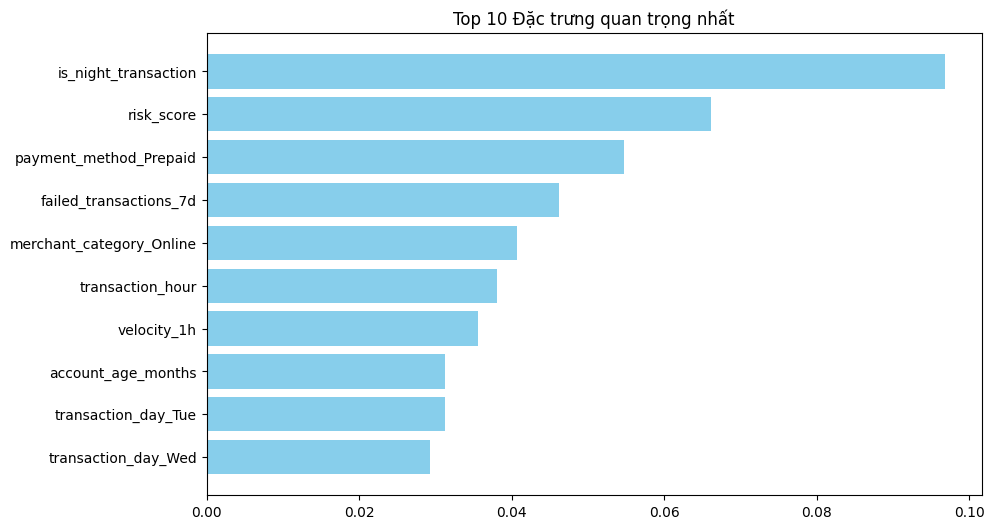

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


num_cols = list(numeric_features)

importances = best_pipe.named_steps['model'].feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': num_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'][:10], feat_imp_df['Importance'][:10], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 10 Đặc trưng quan trọng nhất')
plt.show()

In [28]:
df_res = pd.DataFrame(result)

print(df_res[['Model', 'Mean_F1']])

          Model   Mean_F1
0  RandomForest  0.567763
1       XGBoost  0.570217
2  XGBoost_tune  0.578693


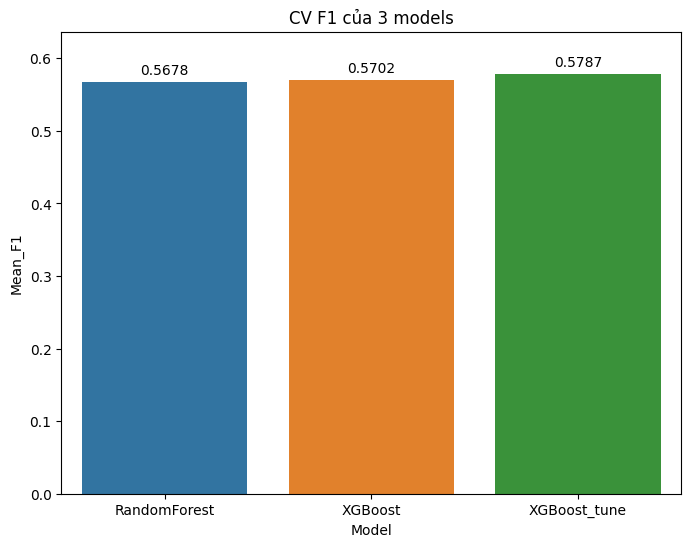

In [34]:
plt.figure(figsize=(8,6))

ax = sns.barplot(
    data=df_res,
    x='Model',
    y='Mean_F1',
    hue='Model'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.title("CV F1 của 3 models")
plt.ylim(0, df_res['Mean_F1'].max() * 1.1) 
plt.show()

Top 3 Feature quan trong nhat la, is_night_transaction, risk_score, payment_method. cung hop ly khi cac giao dich gian lan thuong xay ra ban dem , va chi so kha nang rui ro cao thi anh huong lon, ngoai ra phuong thuc thanh toan on cung la nguy co